In [ ]:
# Example: 84.6 % of all variance in the hand-marker XYZ data is captured by a single direction (PC1). (PC1 is made of many characteristics)

In [ ]:
# Each row that I printed corresponds to a single frame of hand motion from the dataset (i.e. one timestamp).

In [ ]:
# Loadings: These show how much each original variable contributes to each PC.

In [ ]:
# using k-means clustering to group different frames of hand motion based on their positions in PC1–PC2 space since these are most important PC

In [ ]:
#np.roll(y, best_lag)

I0000 00:00:1754315579.657044 8228405 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1754315579.667811 14637815 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1754315579.673675 14637816 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


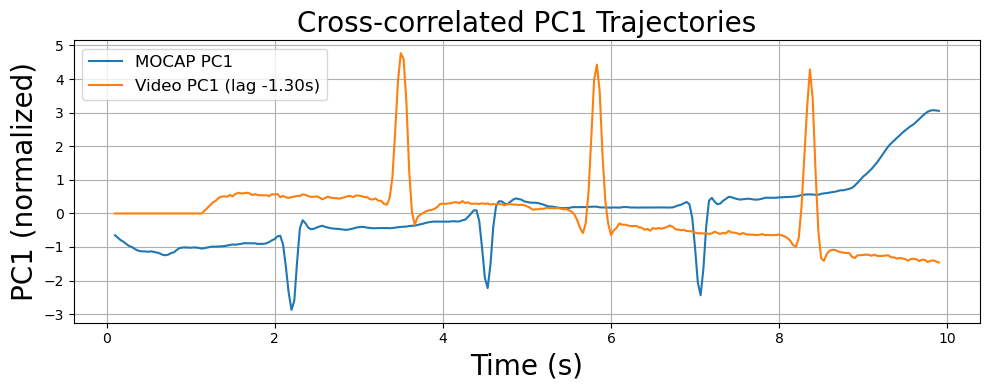

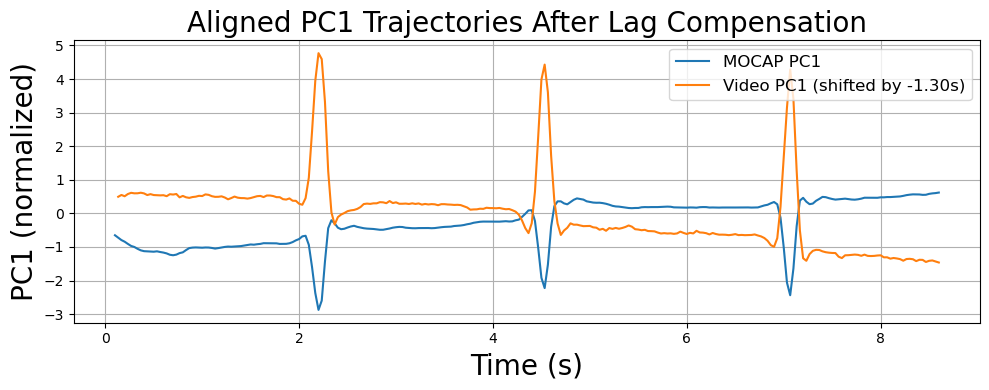

In [102]:
import pandas as pd
import numpy as np
import cv2
import mediapipe as mp
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.signal import correlate
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

# load MOCAP data
df = pd.read_csv("/Users/amy/documents/Parkinsons/AMY_MOCAP.csv", skiprows=8)

# keep wanted columns
df.columns = ["Frame", "Time", "HX", "HY", "HZ", "RX", "RY", "RZ"]
features_mocap = df[["HX", "HY", "HZ"]].dropna().reset_index(drop=True)

# load MOCAP time
time_mocap = df.loc[features_mocap.index, "Time"].reset_index(drop=True).values

# standardize 
scaled_mocap = StandardScaler().fit_transform(features_mocap)

# PCA projection for MOCAP
pc1_mocap = PCA(n_components=1).fit_transform(scaled_mocap).flatten()





# load VIDEO data
video_path = "/Users/amy/documents/Parkinsons/cropped_trimed.mp4"
cap = cv2.VideoCapture(video_path)
fps = cap.get(cv2.CAP_PROP_FPS)  # 30  fps
trajectory = []

# initialize MediaPipe
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.7)

while True:
    success, frame = cap.read()
    if not success:
        break
        
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    results = hands.process(image)
    
    if results.multi_hand_landmarks:
        lm = results.multi_hand_landmarks[0].landmark[8]  # index fingertip
        
        trajectory.append([lm.x, lm.y, lm.z]) # append coordinates
    else:
        trajectory.append([np.nan, np.nan, np.nan])

cap.release()
hands.close()



df_vid = pd.DataFrame(trajectory, columns=["x", "y", "z"])

# interpolate if missing positions
trajectory_interp = df_vid.interpolate(method='linear', limit_direction='both').values

# PCA projection for video
pca_video = PCA(n_components=3).fit(trajectory_interp)

first_pc_vec = pca_video.components_[0]
pc1_video = trajectory_interp @ first_pc_vec

# create time array for plotting based on fps
time_video = np.arange(len(pc1_video)) / fps


# Use the overlapping time segment between mocap and video
t_start = max(time_mocap[0], time_video[0])
t_end = min(time_mocap[-1], time_video[-1])


valid_idx = (time_video >= t_start) & (time_video <= t_end)

# final valid time array
t_common = time_video[valid_idx]


# interpolation for MOCAP
interp_mocap = interp1d(time_mocap, pc1_mocap, kind='linear', fill_value='extrapolate')
pc1_mocap_interp = interp_mocap(t_common)

# interpolation for VIDEO
pc1_video_interp = pc1_video[valid_idx] 

# normalize
x = (pc1_mocap_interp - np.mean(pc1_mocap_interp)) / np.std(pc1_mocap_interp)
y = (pc1_video_interp - np.mean(pc1_video_interp)) / np.std(pc1_video_interp)





# Force same length for correlation
min_len = min(len(x), len(y))
x = x[:min_len]
y = y[:min_len]

# Use absolute values just for correlation
corr = correlate(np.abs(x), np.abs(y), mode='full')
delay_samples = np.argmax(corr) - len(y) + 1

# Time lag in seconds
dt = np.mean(np.diff(t_common))
lag_seconds = delay_samples * dt


# PLOT
plt.figure(figsize=(10, 4))

# PLOTS
plt.plot(t_common, x, label="MOCAP PC1")
plt.plot(t_common, y, label=f"Video PC1 (lag {lag_seconds:.2f}s)")



plt.xlabel("Time (s)", fontsize = 20)
plt.ylabel("PC1 (normalized)", fontsize = 20)
plt.title("Cross-correlated PC1 Trajectories", fontsize = 20)
plt.legend(fontsize = 12)
plt.grid(True)
plt.tight_layout()
plt.show()




# align

# common T
t_min = max(t_common[0], time_video_aligned[0])
t_max = min(t_common[-1], time_video_aligned[-1])

valid_plot_idx = (t_common >= t_min) & (t_common <= t_max)
valid_video_idx = (time_video_aligned >= t_min) & (time_video_aligned <= t_max)

plt.figure(figsize=(10, 4))
plt.plot(t_common[valid_plot_idx], x[valid_plot_idx], label="MOCAP PC1")
plt.plot(time_video_aligned[valid_video_idx], y[valid_video_idx], label=f"Video PC1 (shifted by {lag_seconds:.2f}s)")
plt.xlabel("Time (s)",fontsize = 20)
plt.ylabel("PC1 (normalized)",fontsize = 20)
plt.title("Aligned PC1 Trajectories After Lag Compensation", fontsize = 20)
plt.legend(fontsize = 12)
plt.grid(True)
plt.tight_layout()
plt.show()
